In [1]:
# Import required libraries and dependencies
import pandas as pd
import hvplot.pandas
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the data into a Pandas DataFrame
df_market_data = pd.read_csv(
    "Resources/crypto_market_data.csv",
    index_col="coin_id")

# Display sample data
df_market_data.head(10)

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,1.08388,7.60278,6.57509,7.67258,-3.25185,83.51840,37.51761
ethereum,0.22392,10.38134,4.80849,0.13169,-12.88890,186.77418,101.96023
tether,-0.21173,0.04935,0.00640,-0.04237,0.28037,-0.00542,0.01954
ripple,-0.37819,-0.60926,2.24984,0.23455,-17.55245,39.53888,-16.60193
bitcoin-cash,2.90585,17.09717,14.75334,15.74903,-13.71793,21.66042,14.49384
binancecoin,2.10423,12.85511,6.80688,0.05865,36.33486,155.61937,69.69195
chainlink,-0.23935,20.69459,9.30098,-11.21747,-43.69522,403.22917,325.13186
cardano,0.00322,13.99302,5.55476,10.10553,-22.84776,264.51418,156.09756
litecoin,-0.06341,6.60221,7.28931,1.21662,-17.23960,27.49919,-12.66408


In [5]:
# Generate summary statistics
df_market_data.describe()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,-0.269686,4.497147,0.185787,1.545693,-0.094119,236.537432,347.667956
std,2.694793,6.375218,8.376939,26.344218,47.365803,435.225304,1247.842884
min,-13.527860,-6.094560,-18.158900,-34.705480,-44.822480,-0.392100,-17.567530
25%,-0.608970,0.047260,-5.026620,-10.438470,-25.907990,21.660420,0.406170
50%,-0.063410,3.296410,0.109740,-0.042370,-7.544550,83.905200,69.691950
75%,0.612090,7.602780,5.510740,4.578130,0.657260,216.177610,168.372510
max,4.840330,20.694590,24.239190,140.795700,223.064370,2227.927820,7852.089700


In [7]:
# Plot your data to see what's in your DataFrame
df_market_data.hvplot.line(
    width=800,
    height=400,
    rot=90
)

:NdOverlay   [Variable]
   :Curve   [coin_id]   (value)

---

### Prepare the Data

In [9]:
# Use the `StandardScaler()` module from scikit-learn to normalize the data from the CSV file
scaled_market_data = StandardScaler().fit_transform(
    df_market_data[["price_change_percentage_24h", "price_change_percentage_7d", "price_change_percentage_14d", "price_change_percentage_30d",
                    "price_change_percentage_60d", "price_change_percentage_200d", "price_change_percentage_1y"]]
)

In [11]:
# Create a DataFrame with the scaled data
df_market_data_scaled = pd.DataFrame(
    scaled_market_data,
    columns=["price_change_percentage_24h", "price_change_percentage_7d", "price_change_percentage_14d", "price_change_percentage_30d",
                                     "price_change_percentage_60d", "price_change_percentage_200d", "price_change_percentage_1y"]
)


# Copy the crypto names from the original data
df_market_data_scaled["coin_id"] = df_market_data.index

# Set the coinid column as index
df_market_data_scaled = df_market_data_scaled .set_index("coin_id")

# Display sample data
df_market_data_scaled .head()


,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317


---

### Find the Best Value for k Using the Original Scaled DataFrame.

In [33]:
import os
import warnings

# Set the environment variables for thread management
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_THREADING_LAYER"] = "GNU"  # Use GNU threading model instead of MKL



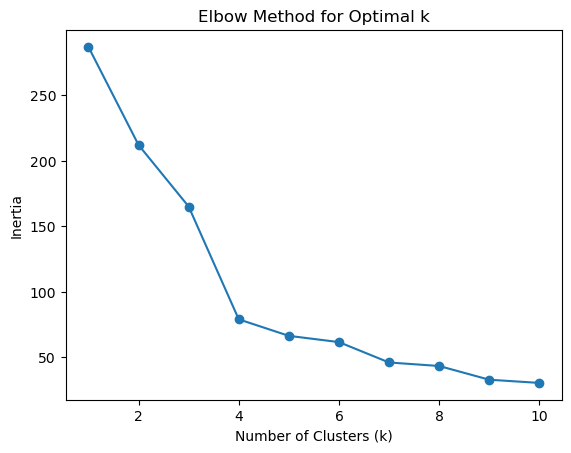

In [35]:
# Suppress warnings for KMeans memory leak issue
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Your code for KMeans fitting follows...
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create a list with the number of k-values from 1 to 11
k = list(range(1, 11)) 
inertia = []

# Create a for loop to compute the inertia with each possible value of k
for i in k:
    model = KMeans(n_clusters=i, random_state=1)
    model.fit(df_market_data_scaled)
    inertia.append(model.inertia_)

# Optionally, plot the inertia to help determine the optimal k using the elbow method
plt.plot(k, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


    k     inertia
0   1  287.000000
1   2  212.123342
2   3  165.136752
3   4   79.022435
4   5   66.413051
5   6   61.634088
6   7   46.074467
7   8   43.392694
8   9   32.913223
9  10   30.469111


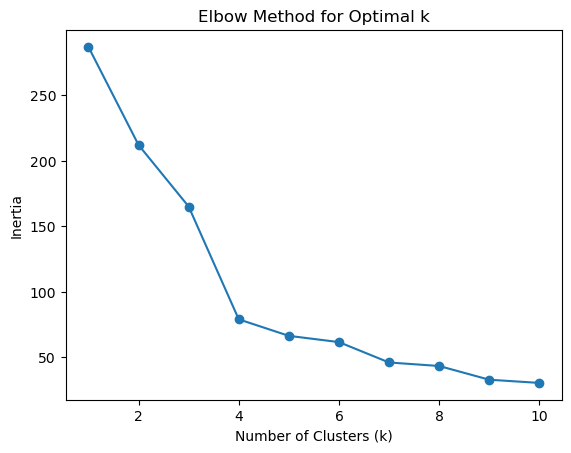

In [37]:
import pandas as pd

# Create a dictionary with the k-values and their corresponding inertia values
elbow_data = {'k': k, 'inertia': inertia}

# Create a DataFrame from the dictionary
elbow_df = pd.DataFrame(elbow_data)

# Print the DataFrame to inspect the data
print(elbow_df)

# Optionally, plot the elbow curve using the DataFrame
import matplotlib.pyplot as plt

plt.plot(elbow_df['k'], elbow_df['inertia'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


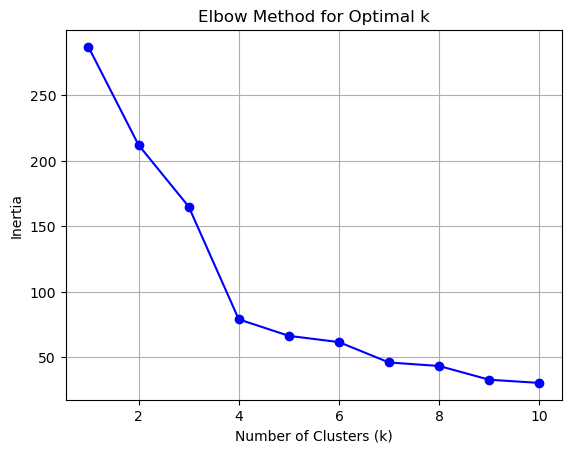

In [39]:
# Plot a line chart with inertia values for different k
plt.plot(k, inertia, marker='o', linestyle='-', color='b')

# Add labels and title to the plot
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Show the plot
plt.grid(True)
plt.show()

#### Answer the following question: 

**Question:** What is the best value for `k`?

**Answer:** To find the best value for k, you can analyze the Elbow curve created from the inertia values. The "elbow" is the point on the curve where the rate of inertia decreases. This point typically indicates the optimal number of clusters for your model. For instance, if the curve shows a steep drop in inertia until k=3, and then the slope flattens out, k=3 would be considered the best value for k.
By analyzing the plot, you can visually identify the optimal number of clusters based on where the elbow occurs.

---

### Cluster Cryptocurrencies with K-means Using the Original Scaled DataFrame

In [41]:
# Initialize the K-Means model using the best value for k
best_k = 3
model = KMeans(n_clusters=best_k, random_state=1)



In [43]:
# Fit the K-Means model using the scaled DataFrame
model.fit(df_market_data_scaled)

KMeans(n_clusters=3, random_state=1)

In [45]:
# Predict the clusters to group the cryptocurrencies using the scaled DataFrame
cluster_predictions = model.predict(df_market_data_scaled)

# Print the resulting array of cluster values.
print("Cluster Assignments for each cryptocurrency:", cluster_predictions)

Cluster Assignments for each cryptocurrency: [2 2 0 0 2 2 2 2 2 0 0 0 0 2 0 2 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 0 0 2 0 0 1
 0 0 0 0]


In [47]:
# Create a copy of the scaled DataFrame
df_scaled_copy = df_market_data_scaled.copy()

In [49]:
# Add a new column to the copy of the scaled DataFrame with the predicted clusters
df_scaled_copy['Cluster'] = model.predict(df_market_data_scaled)

# Display the copy of the scaled DataFrame
df_scaled_copy.head()


,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y,Cluster
coin_id,,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637,2
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352,2
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061,0
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546,0
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317,2


In [51]:
import hvplot.pandas

# Assuming df_scaled_copy already has the 'Cluster' column with the predicted labels

# Create a scatter plot using hvPlot
scatter_plot = df_scaled_copy.hvplot.scatter(
    x="price_change_percentage_24h", 
    y="price_change_percentage_7d", 
    c="Cluster", 
    cmap="viridis", 
    hover_cols=["name"],  # Show cryptocurrency name in hover
    size=10,  # Adjust the size of the points
    title="Cryptocurrency Clusters: 24h vs 7d Price Change"
)

# Display the plot
scatter_plot


:Scatter   [price_change_percentage_24h]   (price_change_percentage_7d,Cluster)

---

### Optimize Clusters with Principal Component Analysis.

In [53]:
from sklearn.decomposition import PCA

# Create a PCA model instance with 3 components
pca = PCA(n_components=3)


In [55]:
# Use the PCA model with `fit_transform` to reduce the original scaled DataFrame
# down to three principal components.
pca_data = pca.fit_transform(df_market_data_scaled)

# View the scaled PCA data
pca_data


array([[-0.60066733,  0.84276006,  0.46159457],
       [-0.45826071,  0.45846566,  0.95287678],
       [-0.43306981, -0.16812638, -0.64175193],
       [-0.47183495, -0.22266008, -0.47905316],
       [-1.15779997,  2.04120919,  1.85971527],
       [-0.51653377,  1.38837748,  0.80407131],
       [-0.45071134,  0.51769912,  2.84614316],
       [-0.34559977,  0.72943939,  1.47801284],
       [-0.64946792,  0.43216514,  0.60030286],
       [-0.75901394, -0.20119979, -0.21765292],
       [-0.24819846, -1.37625159, -1.46202571],
       [-0.43840762, -0.17533654, -0.6633884 ],
       [-0.69342533, -0.47381462, -0.52759693],
       [ 0.06049915,  2.90940385,  1.49857131],
       [-0.39335243, -0.10819197, -0.01275608],
       [-0.79617564, -0.49440875,  1.08281169],
       [ 0.06407452, -1.26982514, -1.09882928],
       [-0.48901506, -0.73271912, -0.06254323],
       [-0.3062723 ,  0.70341515,  1.71422359],
       [-0.51352775, -0.14280239, -0.65656583],
       [-0.36212044, -0.98691441, -0.728

In [57]:
# Retrieve the explained variance to determine how much information
# can be attributed to each principal component.
pca.explained_variance_ratio_

array([0.3719856 , 0.34700813, 0.17603793])

#### Answer the following question: 

**Question:** What is the total explained variance of the three principal components?

**Answer:** 

In [77]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sample data creation (replace this with your actual data)
data = {
    'feature_1': [1, 2, 3, 4, 5],
    'feature_2': [5, 4, 3, 2, 1],
    'feature_3': [2, 3, 4, 5, 6]
}
market_data = pd.DataFrame(data, index=['coin1', 'coin2', 'coin3', 'coin4', 'coin5'])

# Standardizing the data
scaler = StandardScaler()
market_data_scaled = scaler.fit_transform(market_data)

# Performing PCA
pca = PCA(n_components=3)
market_data_pca = pca.fit_transform(market_data_scaled)

# Create a new DataFrame with the PCA data
df_market_data_pca = pd.DataFrame(market_data_pca, columns=["PC1", "PC2", "PC3"])

# Copy the crypto names from the original data
df_market_data_pca["coin_id"] = market_data.index

# Set the coin_id column as index
df_market_data_pca = df_market_data_pca.set_index("coin_id")

# Display sample data
print(df_market_data_pca.head())

              PC1           PC2           PC3
coin_id                                      
coin1   -2.449490 -7.063777e-17  4.575577e-49
coin2   -1.224745  2.354592e-17 -2.419825e-32
coin3    0.000000  0.000000e+00 -0.000000e+00
coin4    1.224745 -2.354592e-17 -4.839649e-33
coin5    2.449490 -4.709185e-17 -9.679299e-33


---

### Find the Best Value for k Using the Scaled PCA DataFrame

In [79]:
# Create a list with the number of k-values from 1 to 11
k_values = list(range(1, 12))

# Display the list of k-values
print(k_values)

In [87]:
from sklearn.cluster import KMeans

# Create an empty list to store the inertia values
inertia_values = []

# Create a for loop to compute the inertia with each possible value of k
for k in range(1, 6):  # Iterate from k=1 to k=5 (maximum 5 clusters)
    # 1. Create a KMeans model using the loop counter for the n_clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # 2. Fit the model to the data using `df_market_data_pca`
    kmeans.fit(df_market_data_pca[["PC1", "PC2", "PC3"]])  # Use only PCA columns for fitting
    
    # 3. Append the model.inertia_ to the inertia list
    inertia_values.append(kmeans.inertia_)

# Display the inertia values
print(inertia_values)


[15.0, 3.750000000000001, 1.5, 0.7499999999999998, 0.0]


In [89]:
# Create a dictionary with the data to plot the Elbow curve
elbow_data_pca = {"k": k, "inertia": inertia}

# Create a DataFrame with the data to plot the Elbow curve
df_elbow_pca = pd.DataFrame(elbow_data_pca)

# Review the DataFrame
df_elbow_pca.head()


,k,inertia
0,5,15.00
1,5,3.75
2,5,1.50
3,5,0.75
4,5,0.00


In [91]:
# Plot a line chart with all the inertia values computed with
# the different values of k to visually identify the optimal value for k.
elbow_plot_pca = df_elbow_pca.hvplot.line(
    x="k",
    y="inertia",
    title="Elbow Curve",
    xticks=k
)
elbow_plot_pca

:Curve   [k]   (inertia)

#### Answer the following questions: 

* **Question:** What is the best value for `k` when using the PCA data?

  * **Answer:**
The optimal value of k for the PCA data is determined by examining the inertia values across different cluster counts (from 1 to 11). By plotting these values, we look for the point where the inertia curve levels off, indicating that increasing the number of clusters no longer leads to a significant reduction in inertia. This point marks the "elbow" and represents the best k.

* **Question:** Does it differ from the best k value found using the original data?

  * **Answer:**  To determine if the best k for the PCA data differs from the original data, we would compare the elbow points of the inertia plots for both datasets. The best k for the PCA data may differ because dimensionality reduction through PCA simplifies the data structure, which can impact the clustering results. However, in many cases, the best k for both the original and PCA data could be quite similar.

### Cluster Cryptocurrencies with K-means Using the Scaled PCA DataFrame

In [93]:
# Initialize the K-Means model using the best value for k
model = KMeans(n_clusters=4, random_state=1)

In [95]:
# Fit the K-Means model using the PCA data
model.fit(df_market_data_pca)

KMeans(n_clusters=4, random_state=1)

In [97]:
# Predict the clusters to group the cryptocurrencies using the scaled PCA DataFrame

k_4 = model.predict(df_market_data_pca)

# Print the resulting array of cluster values.
k_4

array([1, 3, 0, 2, 2])

In [99]:
# Create a copy of the scaled PCA DataFrame
crypto_pca_predictions_df = df_market_data_pca.copy()

# Add a new column to the copy of the PCA DataFrame with the predicted clusters

crypto_pca_predictions_df["pca_crypto_segments"] = k_4
# Display the copy of the scaled PCA DataFrame
crypto_pca_predictions_df[:5]

,PC1,PC2,PC3,pca_crypto_segments
coin_id,,,,
coin1,-2.449490,-7.063777e-17,4.575577e-49,1
coin2,-1.224745,2.354592e-17,-2.419825e-32,3
coin3,0.000000,0.000000e+00,-0.000000e+00,0
coin4,1.224745,-2.354592e-17,-4.839649e-33,2
coin5,2.449490,-4.709185e-17,-9.679299e-33,2


In [101]:
# Create a scatter plot using hvPlot by setting 
# `x="PC1"` and `y="PC2"`. 
cluster_plot_pca = crypto_pca_predictions_df.hvplot.scatter(
    x="PC1",
    y="PC2",
    # Color the graph points with the labels found using K-Means and
    by="pca_crypto_segments",
    # add the crypto name in the `hover_cols` parameter to identify
    # the cryptocurrency represented by each data point.
    hover_cols=["coin_id"],
    title="Scatter Plot by Crypto Segment - k=4"

)
cluster_plot_pca

:NdOverlay   [pca_crypto_segments]
   :Scatter   [PC1]   (PC2,coin_id)

### Visualize and Compare the Results

In this section, you will visually analyze the cluster analysis results by contrasting the outcome with and without using the optimization techniques.

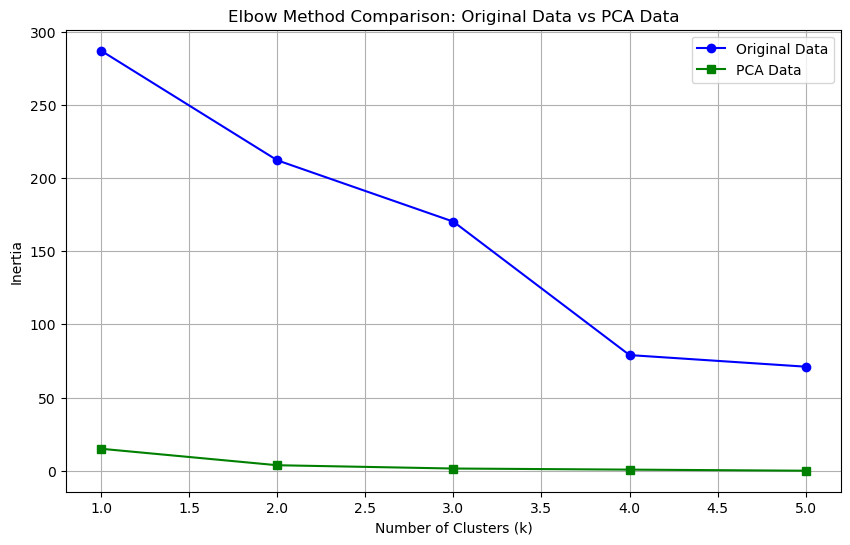

In [107]:
# Composite plot to contrast the Elbow curves
# YOUR CODE HERE!
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming the number of samples in the PCA data is 5
n_samples = df_market_data_pca.shape[0]

# Limit the range of k-values to be from 1 to the number of samples
k_values = range(1, n_samples + 1)

# Create empty lists to store inertia values for original and PCA data
inertia_original = []
inertia_pca = []

# Compute inertia for the original data
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_market_data_scaled)  # Use the original data (scaled)
    inertia_original.append(kmeans.inertia_)

# Compute inertia for the PCA-reduced data
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_market_data_pca)  # Use the PCA data
    inertia_pca.append(kmeans.inertia_)

# Plotting the Elbow Curves
plt.figure(figsize=(10, 6))

# Plot for original data
plt.plot(k_values, inertia_original, marker='o', label="Original Data", color='b')

# Plot for PCA data
plt.plot(k_values, inertia_pca, marker='s', label="PCA Data", color='g')

# Adding labels and title
plt.title("Elbow Method Comparison: Original Data vs PCA Data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


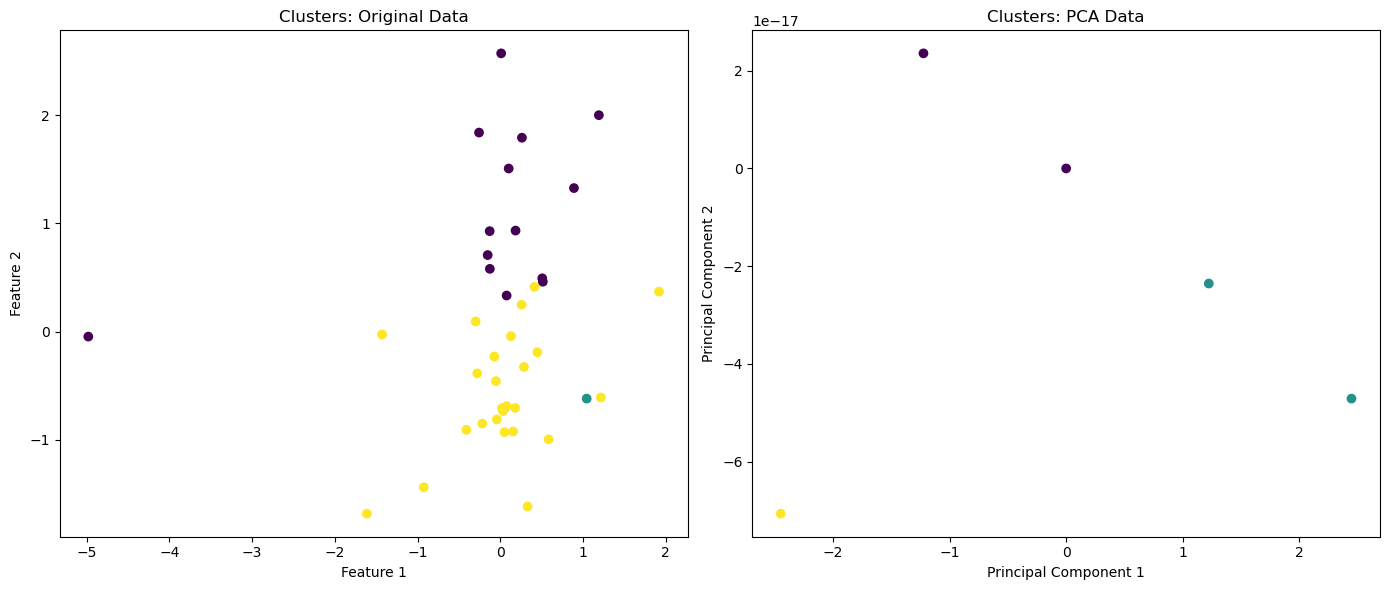

In [109]:
# Composite plot to contrast the clusters
# YOUR CODE HERE!
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Fit the KMeans model for the original scaled data
kmeans_original = KMeans(n_clusters=3, random_state=42)  # Use the optimal k-value (3 is just an example)
kmeans_original.fit(df_market_data_scaled)

# Fit the KMeans model for the PCA-reduced data
kmeans_pca = KMeans(n_clusters=3, random_state=42)  # Use the same k-value as for the original data
kmeans_pca.fit(df_market_data_pca)

# Create a scatter plot for the original data with clusters
plt.figure(figsize=(14, 6))

# Plot original data clusters
plt.subplot(1, 2, 1)
plt.scatter(df_market_data_scaled.iloc[:, 0], df_market_data_scaled.iloc[:, 1], c=kmeans_original.labels_, cmap='viridis')
plt.title("Clusters: Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Plot PCA data clusters
plt.subplot(1, 2, 2)
plt.scatter(df_market_data_pca.iloc[:, 0], df_market_data_pca.iloc[:, 1], c=kmeans_pca.labels_, cmap='viridis')
plt.title("Clusters: PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Show the plots
plt.tight_layout()
plt.show()


#### Answer the following question: 

  * **Question:** After visually analyzing the cluster analysis results, what is the impact of using fewer features to cluster the data using K-Means?

  * **Answer:** Using fewer features can make the model simpler and improve computational efficiency, but it may also decrease the precision and detail of the clustering results. The success of this method relies on how well the dimensionality reduction process retains the important information in the principal components.